In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

# Read the Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
hp= pd.read_excel('/content/drive/My Drive/python files/innercity.xlsx')
hp.head()

,cid,dayhours,price,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,...,basement,yr_built,yr_renovated,zipcode,lat,long,living_measure15,lot_measure15,furnished,total_area
0,3876100940,20150427T000000,600000,4.0,1.75,3050.0,9440.0,1,0,0.0,...,1250.0,1966,0,98034,47.7228,-122.183,2020.0,8660.0,0.0,12490
1,3145600250,20150317T000000,190000,2.0,1.00,670.0,3101.0,1,0,0.0,...,0.0,1948,0,98118,47.5546,-122.274,1660.0,4100.0,0.0,3771
2,7129303070,20140820T000000,735000,4.0,2.75,3040.0,2415.0,2,1,4.0,...,0.0,1966,0,98118,47.5188,-122.256,2620.0,2433.0,0.0,5455
3,7338220280,20141010T000000,257000,3.0,2.50,1740.0,3721.0,2,0,0.0,...,0.0,2009,0,98002,47.3363,-122.213,2030.0,3794.0,0.0,5461
4,7950300670,20150218T000000,450000,2.0,1.00,1120.0,4590.0,1,0,0.0,...,0.0,1924,0,98118,47.5663,-122.285,1120.0,5100.0,0.0,5710


In [5]:
hp.shape

(21613, 23)

In [6]:
### Let's examine the target column which is price
pd.set_option('float_format', '{:f}'.format)
hp.describe().T

,count,mean,std,min,25%,50%,75%,max
cid,21613.000000,4580301520.864988,2876565571.312057,1000102.000000,2123049194.000000,3904930410.000000,7308900445.000000,9900000190.000000
price,21613.000000,540182.158793,367362.231718,75000.000000,321950.000000,450000.000000,645000.000000,7700000.000000
room_bed,21505.000000,3.371355,0.930289,0.000000,3.000000,3.000000,4.000000,33.000000
room_bath,21505.000000,2.115171,0.770248,0.000000,1.750000,2.250000,2.500000,8.000000
living_measure,21596.000000,2079.860761,918.496121,290.000000,1429.250000,1910.000000,2550.000000,13540.000000
lot_measure,21571.000000,15104.583283,41423.619385,520.000000,5040.000000,7618.000000,10684.500000,1651359.000000
sight,21556.000000,0.234366,0.766438,0.000000,0.000000,0.000000,0.000000,4.000000
quality,21612.000000,7.656857,1.175484,1.000000,7.000000,7.000000,8.000000,13.000000
ceil_measure,21612.000000,1788.366556,828.102535,290.000000,1190.000000,1560.000000,2210.000000,9410.000000
basement,21612.000000,291.522534,442.580840,0.000000,0.000000,0.000000,560.000000,4820.000000


In [7]:
hp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cid               21613 non-null  int64  
 1   dayhours          21613 non-null  object 
 2   price             21613 non-null  int64  
 3   room_bed          21505 non-null  float64
 4   room_bath         21505 non-null  float64
 5   living_measure    21596 non-null  float64
 6   lot_measure       21571 non-null  float64
 7   ceil              21571 non-null  object 
 8   coast             21612 non-null  object 
 9   sight             21556 non-null  float64
 10  condition         21556 non-null  object 
 11  quality           21612 non-null  float64
 12  ceil_measure      21612 non-null  float64
 13  basement          21612 non-null  float64
 14  yr_built          21612 non-null  object 
 15  yr_renovated      21613 non-null  int64  
 16  zipcode           21613 non-null  int64 

In [8]:
### Examine missing values
hp1 = hp.isna().sum()
hp1[hp1.values > 0].sort_values(ascending=False) # Find out all variables that contain missing values

living_measure15    166
room_bed            108
room_bath           108
sight                57
condition            57
lot_measure          42
ceil                 42
lot_measure15        29
furnished            29
total_area           29
living_measure       17
coast                 1
quality               1
ceil_measure          1
basement              1
yr_built              1
dtype: int64

In [9]:
hp.replace({ 'ceil': { '$' : 'Nan' },'coast': { '$' : 'Nan'},'condition': { '$' : 'Nan'},'yr_built': { '$' : 'Nan'},
           'long': { '$' : 'Nan'},'total_area': { '$' : 'Nan'}},inplace=True)

In [10]:
for i in range(0,len(hp)):
    hp['sold_date']=hp.iloc[i].dayhours[:8]

hp.drop('dayhours', axis=1,inplace=True)
hp.head()

,cid,price,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,condition,...,yr_built,yr_renovated,zipcode,lat,long,living_measure15,lot_measure15,furnished,total_area,sold_date
0,3876100940,600000,4.000000,1.750000,3050.000000,9440.000000,1,0,0.000000,3,...,1966,0,98034,47.722800,-122.183000,2020.000000,8660.000000,0.000000,12490,20141229
1,3145600250,190000,2.000000,1.000000,670.000000,3101.000000,1,0,0.000000,4,...,1948,0,98118,47.554600,-122.274000,1660.000000,4100.000000,0.000000,3771,20141229
2,7129303070,735000,4.000000,2.750000,3040.000000,2415.000000,2,1,4.000000,3,...,1966,0,98118,47.518800,-122.256000,2620.000000,2433.000000,0.000000,5455,20141229
3,7338220280,257000,3.000000,2.500000,1740.000000,3721.000000,2,0,0.000000,3,...,2009,0,98002,47.336300,-122.213000,2030.000000,3794.000000,0.000000,5461,20141229
4,7950300670,450000,2.000000,1.000000,1120.000000,4590.000000,1,0,0.000000,3,...,1924,0,98118,47.566300,-122.285000,1120.000000,5100.000000,0.000000,5710,20141229


In [11]:
impute= ['living_measure','room_bed','room_bath','sight','condition','lot_measure','ceil','lot_measure15','furnished',
         'total_area','living_measure15','coast','quality','ceil_measure','basement','yr_built', 'long']
for i in impute:
    hp[i]=hp[i].astype("float")
    hp[i].fillna(hp[i].mean(),inplace=True)

<ipython-input-12-b3274ad5e152>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  a = sns.distplot(hp[column] , ax=axes[i][j])
<ipython-input-12-b3274ad5e152>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  a = sns.distplot(hp[column] , ax=axes[i][j])
<ipython-input-12-b3274ad5e152>:5: UserWarning: 

`distplot` is a depr

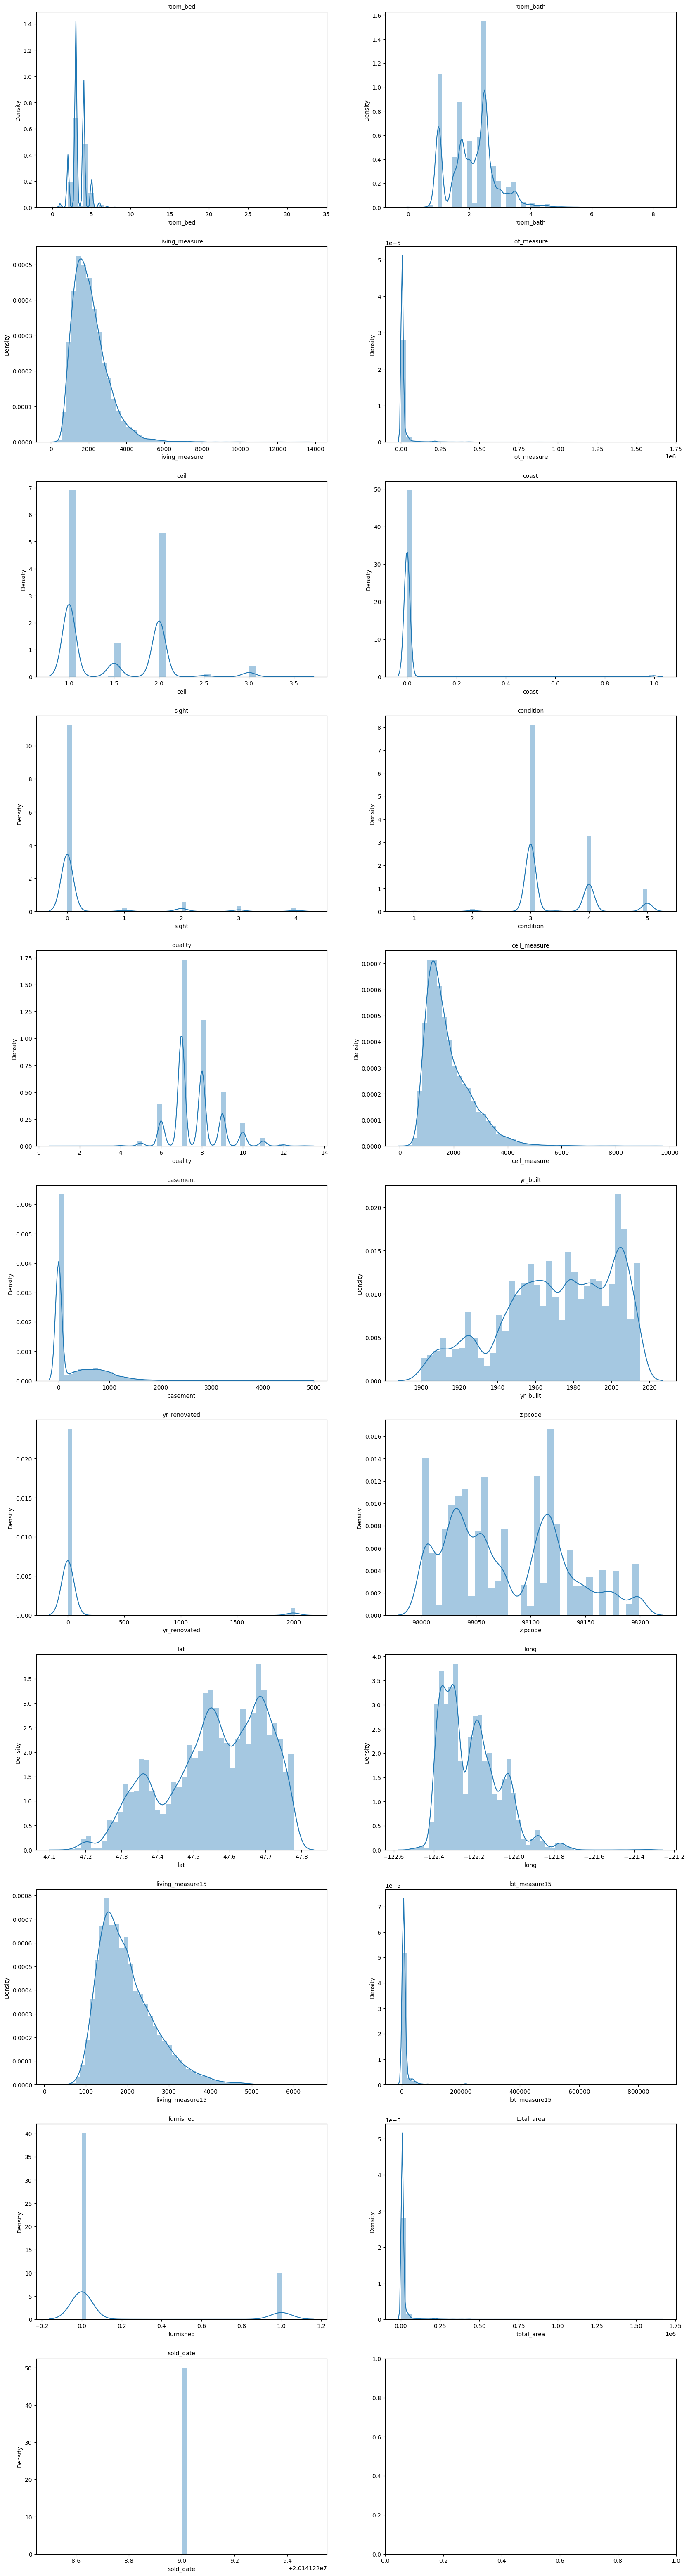

In [12]:
i=j=0
fig, axes = plt.subplots(nrows=11,ncols=2)
fig.set_size_inches(20,80)
for column in hp.iloc[:, 2:24]:
    a = sns.distplot(hp[column] , ax=axes[i][j])
    a.set_title(column,fontsize=10)
    j=j+1
    if j>1:
        i=i+1
        j=0

plt.show()

<Axes: >

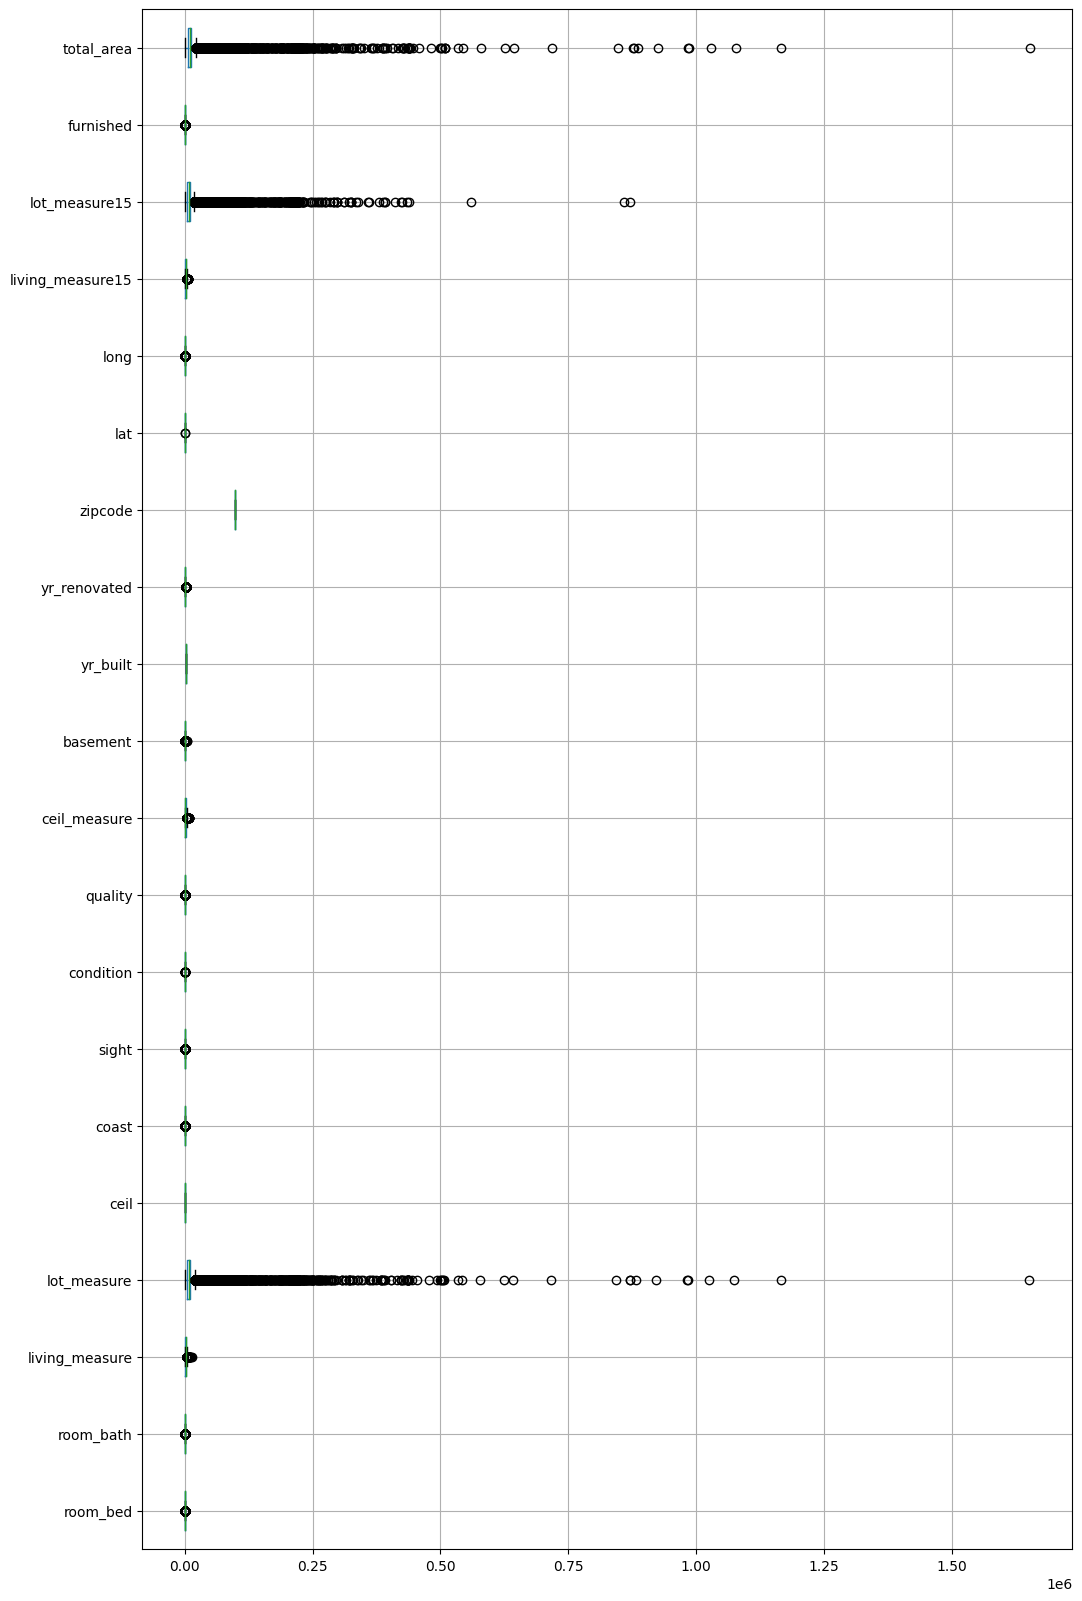

In [13]:
plt.figure(figsize=(12,20))
hp.iloc[:, 2:23].boxplot(vert=0)

In [14]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [15]:
columns=('lot_measure15','lot_measure', 'total_area')
for column in columns:
    lr,ur=remove_outlier(hp[column])
    hp[column]=np.where(hp[column]>ur,ur,hp[column])
    hp[column]=np.where(hp[column]<lr,lr,hp[column])

<Axes: >

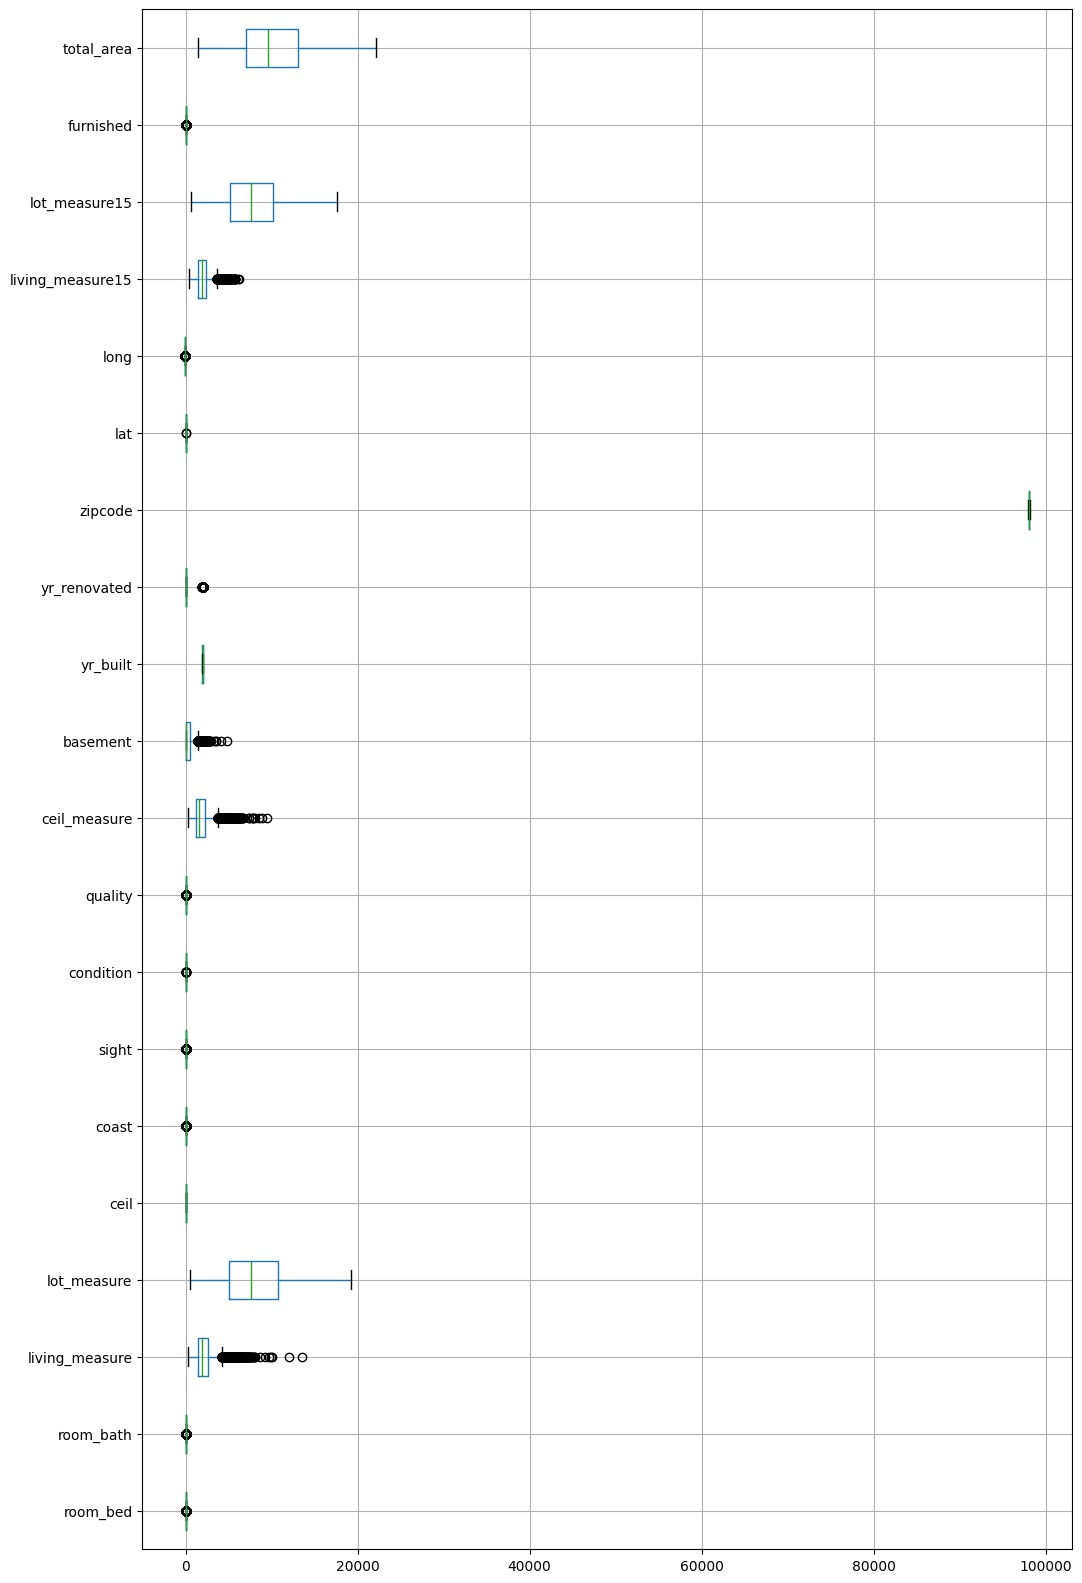

In [16]:
plt.figure(figsize=(12,20))
hp.iloc[:, 2:23].boxplot(vert=0)

In [17]:
hp['age']=2015-hp['yr_built']

In [18]:
hp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cid               21613 non-null  int64  
 1   price             21613 non-null  int64  
 2   room_bed          21613 non-null  float64
 3   room_bath         21613 non-null  float64
 4   living_measure    21613 non-null  float64
 5   lot_measure       21613 non-null  float64
 6   ceil              21613 non-null  float64
 7   coast             21613 non-null  float64
 8   sight             21613 non-null  float64
 9   condition         21613 non-null  float64
 10  quality           21613 non-null  float64
 11  ceil_measure      21613 non-null  float64
 12  basement          21613 non-null  float64
 13  yr_built          21613 non-null  float64
 14  yr_renovated      21613 non-null  int64  
 15  zipcode           21613 non-null  int64  
 16  lat               21613 non-null  float6

<ipython-input-19-cd48a722531c>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(hp.corr(), cmap='Blues', annot=True,annot_kws={"size": 5},)


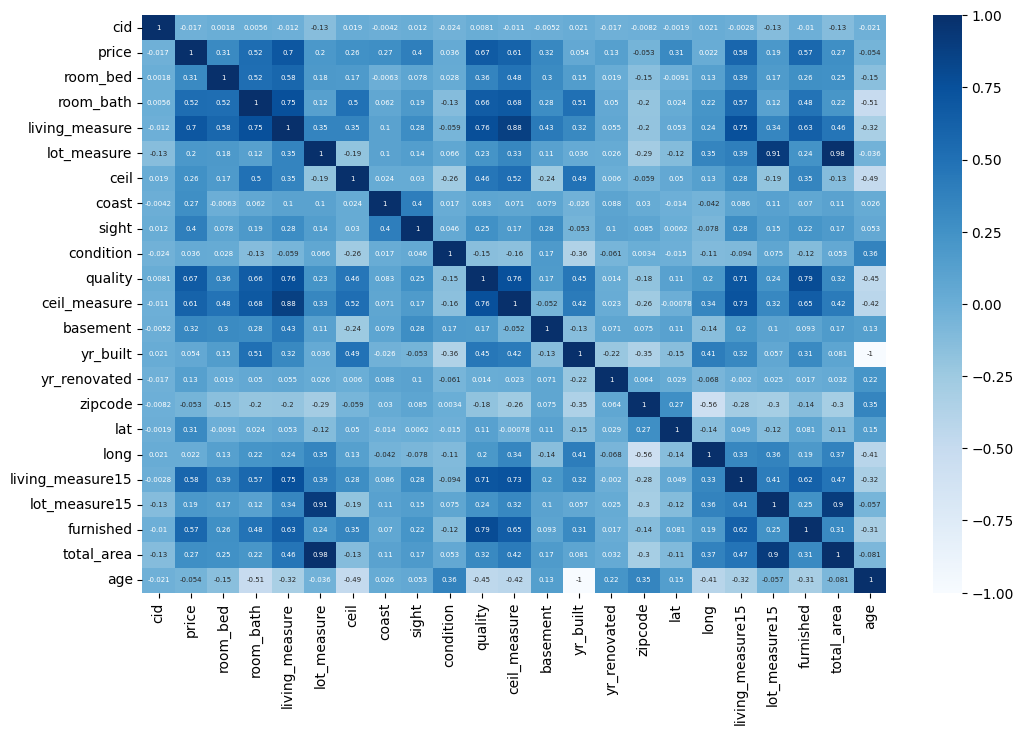

In [19]:
plt.figure(figsize=(12,7.5))
sns.heatmap(hp.corr(), cmap='Blues', annot=True,annot_kws={"size": 5},)
plt.show()

In [20]:
hp3=hp.drop(['cid','zipcode','yr_built','yr_renovated','lat','long','sold_date'],axis=1)

In [21]:
hp3.head()

,price,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,condition,quality,ceil_measure,basement,living_measure15,lot_measure15,furnished,total_area,age
0,600000,4.000000,1.750000,3050.000000,9440.000000,1.000000,0.000000,0.000000,3.000000,8.000000,1800.000000,1250.000000,2020.000000,8660.000000,0.000000,12490.000000,49.000000
1,190000,2.000000,1.000000,670.000000,3101.000000,1.000000,0.000000,0.000000,4.000000,6.000000,670.000000,0.000000,1660.000000,4100.000000,0.000000,3771.000000,67.000000
2,735000,4.000000,2.750000,3040.000000,2415.000000,2.000000,1.000000,4.000000,3.000000,8.000000,3040.000000,0.000000,2620.000000,2433.000000,0.000000,5455.000000,49.000000
3,257000,3.000000,2.500000,1740.000000,3721.000000,2.000000,0.000000,0.000000,3.000000,8.000000,1740.000000,0.000000,2030.000000,3794.000000,0.000000,5461.000000,6.000000
4,450000,2.000000,1.000000,1120.000000,4590.000000,1.000000,0.000000,0.000000,3.000000,7.000000,1120.000000,0.000000,1120.000000,5100.000000,0.000000,5710.000000,91.000000


In [22]:
from scipy.stats import zscore
scaled_hp3=hp3.apply(zscore)


In [23]:
scaled_hp3.head()

,price,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,condition,quality,ceil_measure,basement,living_measure15,lot_measure15,furnished,total_area,age
0,0.162834,0.677463,-0.475295,1.056666,0.140961,-0.916750,-0.086757,-0.306198,-0.630304,0.291930,0.014049,2.165755,0.048230,0.080093,-0.495202,0.306756,0.170603
1,-0.953256,-1.477850,-1.451472,-1.535606,-1.109902,-0.916750,-0.086757,-0.306198,0.909548,-1.409576,-1.350579,-0.658718,-0.478960,-0.962602,-0.495202,-1.291934,0.783629
2,0.530328,0.677463,0.826274,1.045774,-1.245270,0.938541,11.542998,4.919770,-0.630304,0.291930,1.511517,-0.658718,0.926879,-1.343780,-0.495202,-0.983161,0.170603
3,-0.770871,-0.400194,0.500882,-0.370173,-0.987559,0.938541,-0.086757,-0.306198,-0.630304,0.291930,-0.058409,-0.658718,0.062874,-1.032572,-0.495202,-0.982061,-1.293847
4,-0.245491,-1.477850,-1.451472,-1.045471,-0.816081,-0.916750,-0.086757,-0.306198,-0.630304,-0.558823,-0.807143,-0.658718,-1.269745,-0.733941,-0.495202,-0.936405,1.600996


In [24]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters = 2,random_state=1)
k_means.fit(scaled_hp3)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=2, random_state=1)

In [25]:

wss =[]
for i in range(1,16):
    KM = KMeans(n_clusters=i,random_state=1)
    KM.fit(scaled_hp3)
    wss.append(KM.inertia_)
wss

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

[367421.0,
 274924.169054785,
 240329.0314486563,
 216389.12628594946,
 192359.2479644818,
 177292.075508949,
 165054.68928311538,
 157184.03310972464,
 150425.08824222625,
 142679.3902858844,
 136679.12955218423,
 131976.18701310182,
 127820.55292581857,
 124523.7651400299,
 121557.7040837101]

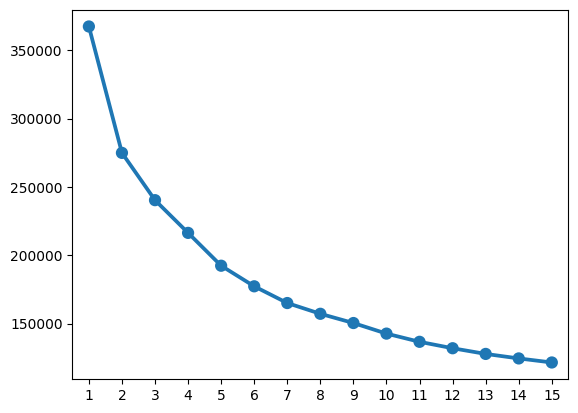

In [26]:
a=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
sns.pointplot(x=a, y=wss);

In [27]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters = 5,random_state=1)
k_means.fit(scaled_hp3)
labels=k_means.labels_


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [28]:
hp["segmentation"] = labels
hp.head()

,cid,price,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,condition,...,zipcode,lat,long,living_measure15,lot_measure15,furnished,total_area,sold_date,age,segmentation
0,3876100940,600000,4.000000,1.750000,3050.000000,9440.000000,1.000000,0.000000,0.000000,3.000000,...,98034,47.722800,-122.183000,2020.000000,8660.000000,0.000000,12490.000000,20141229,49.000000,0
1,3145600250,190000,2.000000,1.000000,670.000000,3101.000000,1.000000,0.000000,0.000000,4.000000,...,98118,47.554600,-122.274000,1660.000000,4100.000000,0.000000,3771.000000,20141229,67.000000,1
2,7129303070,735000,4.000000,2.750000,3040.000000,2415.000000,2.000000,1.000000,4.000000,3.000000,...,98118,47.518800,-122.256000,2620.000000,2433.000000,0.000000,5455.000000,20141229,49.000000,4
3,7338220280,257000,3.000000,2.500000,1740.000000,3721.000000,2.000000,0.000000,0.000000,3.000000,...,98002,47.336300,-122.213000,2030.000000,3794.000000,0.000000,5461.000000,20141229,6.000000,2
4,7950300670,450000,2.000000,1.000000,1120.000000,4590.000000,1.000000,0.000000,0.000000,3.000000,...,98118,47.566300,-122.285000,1120.000000,5100.000000,0.000000,5710.000000,20141229,91.000000,1


In [29]:
hp.segmentation.value_counts().sort_index()

0    4553
1    8180
2    5184
3    3535
4     161
Name: segmentation, dtype: int64

In [36]:

hp.to_excel('/content/drive/My Drive/python files/innercity2.xlsx', index=False)


In [30]:
scaled_hp3["segmentation"]=labels

In [31]:
from factor_analyzer import FactorAnalyzer

ModuleNotFoundError: ignored

In [39]:
hp4=hp3.drop(['price', 'lot_measure','living_measure'],axis=1)
scaled_hp4=hp4.apply(zscore)
scaled_hp4.head()

,room_bed,room_bath,ceil,coast,sight,condition,quality,ceil_measure,basement,living_measure15,lot_measure15,furnished,total_area,age
0,0.677463,-0.475295,-0.916750,-0.086757,-0.306198,-0.630304,0.291930,0.014049,2.165755,0.048230,0.080093,-0.495202,0.306756,0.170603
1,-1.477850,-1.451472,-0.916750,-0.086757,-0.306198,0.909548,-1.409576,-1.350579,-0.658718,-0.478960,-0.962602,-0.495202,-1.291934,0.783629
2,0.677463,0.826274,0.938541,11.542998,4.919770,-0.630304,0.291930,1.511517,-0.658718,0.926879,-1.343780,-0.495202,-0.983161,0.170603
3,-0.400194,0.500882,0.938541,-0.086757,-0.306198,-0.630304,0.291930,-0.058409,-0.658718,0.062874,-1.032572,-0.495202,-0.982061,-1.293847
4,-1.477850,-1.451472,-0.916750,-0.086757,-0.306198,-0.630304,-0.558823,-0.807143,-0.658718,-1.269745,-0.733941,-0.495202,-0.936405,1.600996


In [ ]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(scaled_hp4)
p_value

The Kaiser-Meyer-Olkin (KMO) - measure of sampling adequacy (MSA) is an index used to examine how appropriate PCA is.

Generally, if MSA is less than 0.5, PCA is not recommended, since no reduction is expected. On the other hand, MSA > 0.7 is expected to provide a considerable reduction is the dimension and extraction of meaningful components.

In [38]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model=calculate_kmo(scaled_hp4)
kmo_model

ModuleNotFoundError: ignored

In [41]:
from sklearn.decomposition import PCA
pca = PCA(n_components=8, random_state=123)
df_pca = pca.fit_transform(scaled_hp4)
df_pca.transpose() # Component output

array([[-0.01504349, -3.38507635,  2.42901125, ...,  4.17565213,
        -0.32322934,  0.79775683],
       [ 1.1345718 , -0.12790104,  1.19393221, ...,  0.94002488,
        -1.41355132, -0.74802451],
       [ 0.52129822,  0.20935064,  6.87493663, ..., -1.10503371,
        -0.27865379,  0.93554311],
       ...,
       [-0.61714488, -0.5374032 ,  4.98792841, ..., -0.9410793 ,
         1.20903636, -0.315467  ],
       [ 0.20261186, -0.27028421,  1.27388459, ..., -0.75813773,
        -0.07119103,  1.12875845],
       [ 0.62847195,  0.18346724,  2.50807503, ...,  0.6720537 ,
        -0.41384665,  0.87311894]])

In [42]:
pca.components_

array([[ 0.24150153,  0.35805984,  0.22655443,  0.06193292,  0.13678302,
        -0.08492717,  0.39589743,  0.39974976,  0.08267602,  0.3756698 ,
         0.19086478,  0.34614495,  0.23320014, -0.23928976],
       [ 0.073998  , -0.11530088, -0.43602744,  0.16542321,  0.23240571,
         0.31166867, -0.064468  , -0.07471749,  0.31938081,  0.0965579 ,
         0.4457708 , -0.02379498,  0.43114041,  0.32614297],
       [ 0.15179206,  0.19517963,  0.07115177,  0.3351056 ,  0.45087959,
         0.17378361,  0.07155626, -0.09245573,  0.44711279, -0.02242472,
        -0.44116571,  0.00941693, -0.39301793,  0.15732947],
       [ 0.45569877,  0.20034538, -0.10239606, -0.60015519, -0.40740055,
         0.26280192, -0.00602392,  0.00088521,  0.34931135,  0.00854967,
        -0.1107479 , -0.06700297, -0.06384702,  0.05941009],
       [ 0.17482519,  0.14154676, -0.17386946,  0.08585299,  0.02002706,
        -0.69626598, -0.1635912 , -0.18524596,  0.38042349, -0.07879815,
         0.0927262 , -0.29

In [43]:
var_exp = pca.explained_variance_ratio_
pca.explained_variance_ratio_

array([0.35299126, 0.16062955, 0.10168627, 0.0887848 , 0.06181407,
       0.05552181, 0.04297239, 0.03767841])

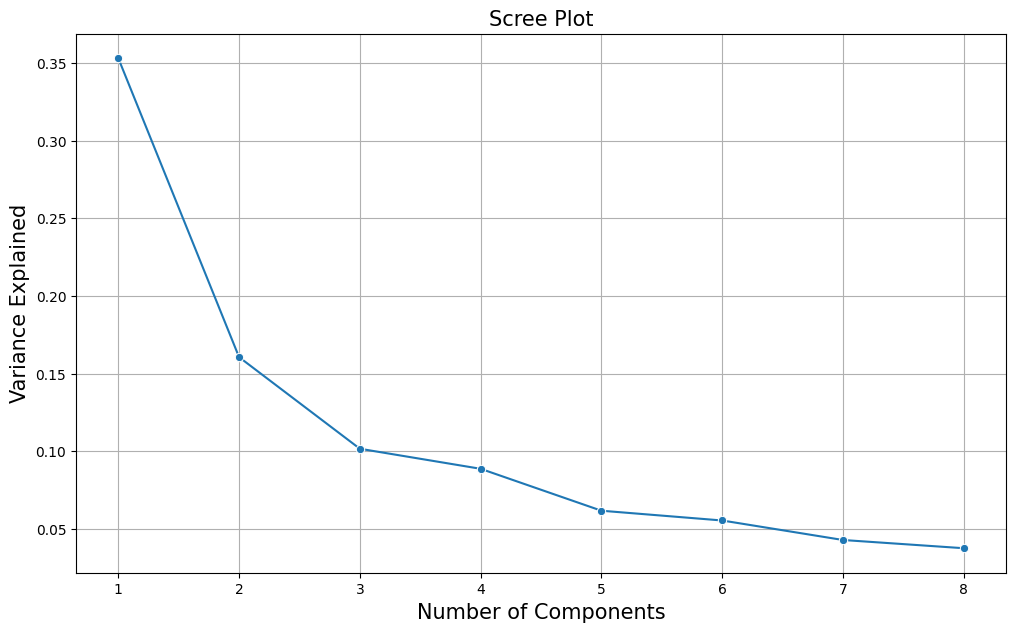

In [44]:
plt.figure(figsize=(12,7))
sns.lineplot(y=var_exp,x=range(1,len(var_exp)+1),marker='o')
plt.xlabel('Number of Components',fontsize=15)
plt.ylabel('Variance Explained',fontsize=15)
plt.title('Scree Plot',fontsize=15)
plt.grid()
plt.show()

In [45]:
temp_pca = pd.DataFrame(pca.components_,columns=list(scaled_hp4))
temp_pca.shape

(8, 14)

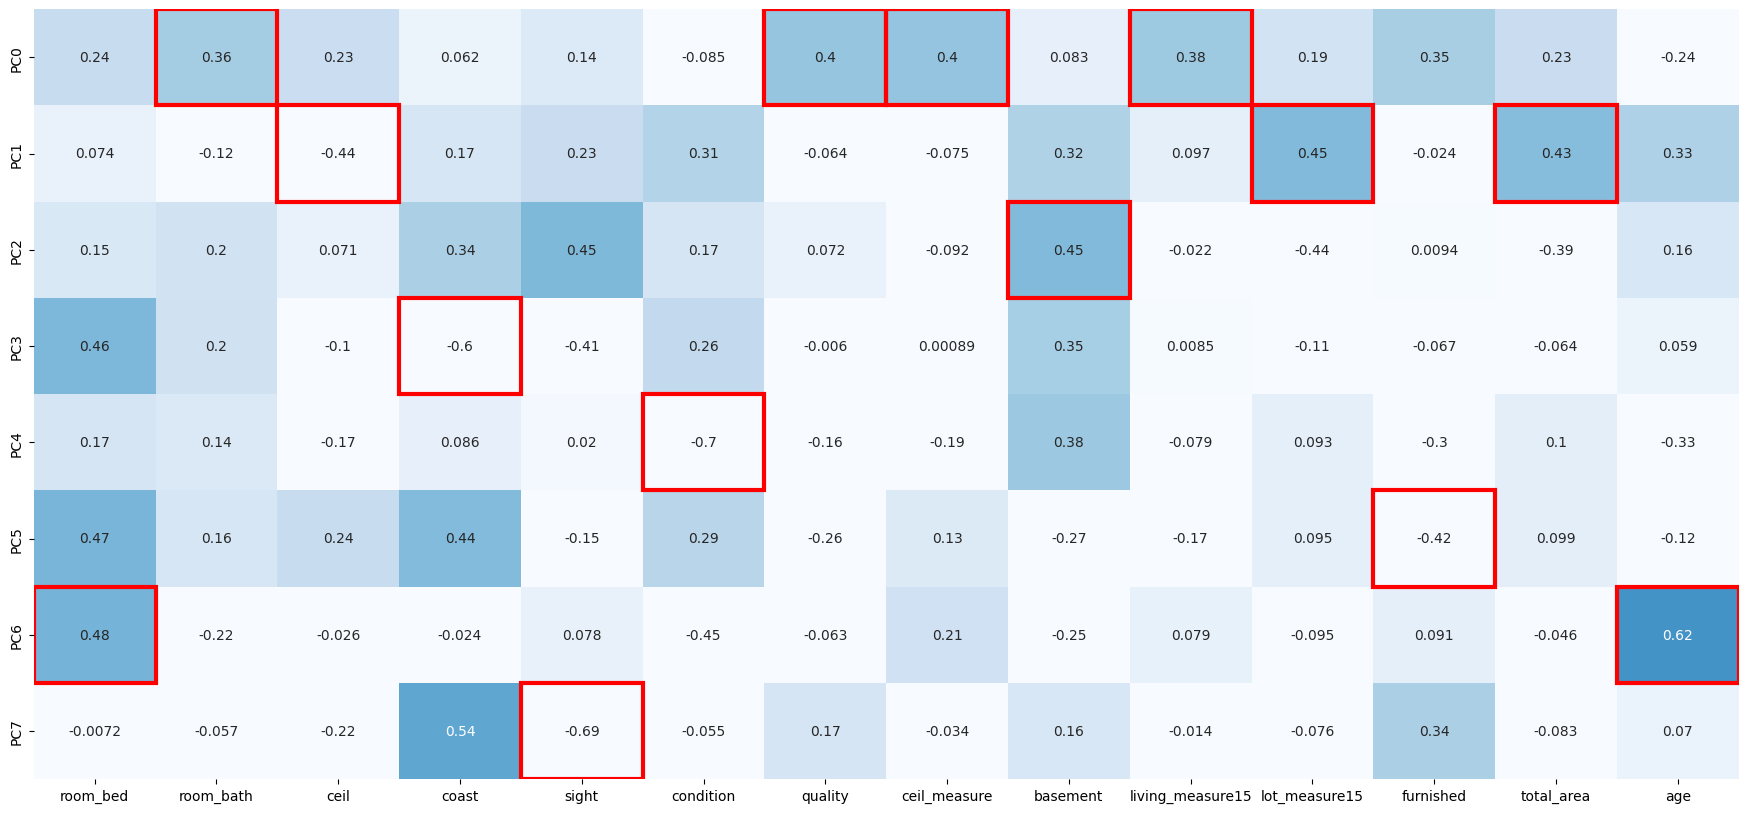

In [46]:
from matplotlib.patches import Rectangle
fig,ax = plt.subplots(figsize=(22, 10), facecolor='w', edgecolor='k')
ax = sns.heatmap(temp_pca, annot=True, vmax=1.0, vmin=0, cmap='Blues', cbar=False, fmt='.2g', ax=ax,
                 yticklabels=['PC0','PC1','PC2','PC3','PC4','PC5','PC6','PC7'])

column_max = temp_pca.abs().idxmax(axis=0)

for col, variable in enumerate(temp_pca.columns):
    position = temp_pca.index.get_loc(column_max[variable])
    ax.add_patch(Rectangle((col, position),1,1, fill=False, edgecolor='red', lw=3))

In [47]:
hp_pca=pd.DataFrame(df_pca,columns=['quality_measure','house_measure','basement','coast','condition',
                                    'furnished','rooms_age','sight'])
hp_pca.head()

,quality_measure,house_measure,basement,coast,condition,furnished,rooms_age,sight
0,-0.015043,1.134572,0.521298,1.088584,1.537694,-0.617145,0.202612,0.628472
1,-3.385076,-0.127901,0.209351,-0.412604,-1.014004,-0.537403,-0.270284,0.183467
2,2.429011,1.193932,6.874937,-8.687081,0.814687,4.987928,1.273885,2.508075
3,0.075082,-2.291214,0.190765,-0.264955,0.340970,0.194920,-0.626282,-0.183032
4,-3.066360,-0.257840,-0.141895,-0.828148,-0.326747,-1.044090,0.886660,0.418789


In [48]:
hp_pca.shape

(21613, 8)

In [49]:
hp_pca["price"]=scaled_hp3.price

In [50]:
hp_pca.head()

,quality_measure,house_measure,basement,coast,condition,furnished,rooms_age,sight,price
0,-0.015043,1.134572,0.521298,1.088584,1.537694,-0.617145,0.202612,0.628472,0.162834
1,-3.385076,-0.127901,0.209351,-0.412604,-1.014004,-0.537403,-0.270284,0.183467,-0.953256
2,2.429011,1.193932,6.874937,-8.687081,0.814687,4.987928,1.273885,2.508075,0.530328
3,0.075082,-2.291214,0.190765,-0.264955,0.340970,0.194920,-0.626282,-0.183032,-0.770871
4,-3.066360,-0.257840,-0.141895,-0.828148,-0.326747,-1.044090,0.886660,0.418789,-0.245491


In [51]:
k_means.fit(hp_pca)
wss =[]
for i in range(1,16):
    KM = KMeans(n_clusters=i,random_state=1)
    KM.fit(hp_pca)
    wss.append(KM.inertia_)
wss

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

[294565.73815799237,
 216044.6398678359,
 184297.4678190739,
 159851.7828637125,
 141166.9542037264,
 130234.06506955795,
 119593.66024867915,
 112775.3279889171,
 106804.16926299255,
 100938.11706766399,
 95667.34169293649,
 92194.30118292337,
 89434.5916149864,
 86250.41490897736,
 83997.34224970057]

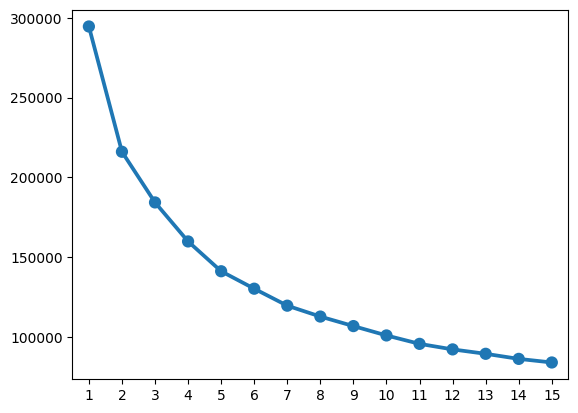

In [52]:
a=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
sns.pointplot(x=a, y=wss);

In [53]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters = 5,random_state=1)
k_means.fit(hp_pca)
labels=k_means.labels_


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [54]:
hp_pca["segmentation"] = labels
hp_pca.head()

,quality_measure,house_measure,basement,coast,condition,furnished,rooms_age,sight,price,segmentation
0,-0.015043,1.134572,0.521298,1.088584,1.537694,-0.617145,0.202612,0.628472,0.162834,0
1,-3.385076,-0.127901,0.209351,-0.412604,-1.014004,-0.537403,-0.270284,0.183467,-0.953256,3
2,2.429011,1.193932,6.874937,-8.687081,0.814687,4.987928,1.273885,2.508075,0.530328,4
3,0.075082,-2.291214,0.190765,-0.264955,0.340970,0.194920,-0.626282,-0.183032,-0.770871,2
4,-3.066360,-0.257840,-0.141895,-0.828148,-0.326747,-1.044090,0.886660,0.418789,-0.245491,3


In [55]:
hp_pca.segmentation.value_counts().sort_index()


0    5416
1    3753
2    4959
3    7324
4     161
Name: segmentation, dtype: int64

# Model Building



## Linear Regression - Base Model

In [56]:
from sklearn.model_selection import train_test_split
X1 = scaled_hp3.drop(['price'], axis=1)
y1 = scaled_hp3['price']
X2 = hp_pca.drop('price', axis=1)
y2 = hp_pca['price']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.30 , random_state=1)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.30 , random_state=1)

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
regression_model = LinearRegression()
model1=regression_model.fit(X1_train, y1_train)



In [58]:
model1.coef_

array([-0.10973166,  0.09876457,  0.2247636 ,  0.12272624,  0.01246105,
        0.13239967,  0.0939144 ,  0.03901717,  0.33565449,  0.20767365,
        0.11466734,  0.06304988, -0.01657357,  0.0347642 , -0.18867748,
        0.28090415,  0.01429294])

In [59]:
regression_model.score(X1_train, y1_train)

0.6558642205183369

In [60]:
regression_model.score(X1_test, y1_test)

0.6619941131468088

In [61]:
predicted_train=regression_model.fit(X1_train, y1_train).predict(X1_train)
predicted_test=regression_model.fit(X1_train, y1_train).predict(X1_test)

In [62]:
def mape(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    mape = np.mean(np.abs((y_test - pred) / y_test))
    return mape

print(mape(y1_train, predicted_train))
print(mape(y1_test, predicted_test))


4.491663270029077
4.612588388390334


In [63]:
from sklearn.metrics import mean_squared_error
RMSE = np.sqrt(mean_squared_error(y1_train,predicted_train))
RMSE1 = np.sqrt(mean_squared_error(y1_test,predicted_test))

print(RMSE)
print(RMSE1)

0.5868060166939097
0.5809742274048084


### KNN Model

In [64]:
from sklearn.neighbors import KNeighborsRegressor

KNN_model=KNeighborsRegressor()
KNN_model.fit(X1_train,y1_train)

KNeighborsRegressor()

In [65]:
y1_train_predict = KNN_model.predict(X1_train)
model_score = KNN_model.score(X1_train, y1_train)
print(model_score)

0.7816983049344552


In [66]:
y1_test_predict = KNN_model.predict(X1_test)
model_score = KNN_model.score(X1_test, y1_test)
print(model_score)

0.7081697408749457


In [67]:
print(mape(y1_train, y1_train_predict))
print(mape(y1_test, y1_test_predict))

3.23130064374195
3.820840914625045


In [68]:
RMSE = np.sqrt(mean_squared_error(y1_train,y1_train_predict))
RMSE1 = np.sqrt(mean_squared_error(y1_test,y1_test_predict))

print(RMSE)
print(RMSE1)

0.4673671653911809
0.5398335791238594


### Random Forest Model

In [69]:
from sklearn.ensemble import RandomForestRegressor

RF_model=RandomForestRegressor(max_depth=10, max_features=6,
                               min_samples_leaf=10, min_samples_split=100, n_estimators=300 ,random_state=1)
RF_model.fit(X1_train, y1_train)

RandomForestRegressor(max_depth=10, max_features=6, min_samples_leaf=10,
                      min_samples_split=100, n_estimators=300, random_state=1)

In [70]:
y1_train_predict = RF_model.predict(X1_train)
model_score =RF_model.score(X1_train, y1_train)
print(model_score)

0.735587746122028


In [71]:
y1_test_predict = RF_model.predict(X1_test)
model_score = RF_model.score(X1_test, y1_test)
print(model_score)

0.7237399644565103


In [72]:
print(mape(y1_train, y1_train_predict))
print(mape(y1_test, y1_test_predict))

3.426434861540259
3.610360283313657


In [73]:
RMSE = np.sqrt(mean_squared_error(y1_train,y1_train_predict))
RMSE1 = np.sqrt(mean_squared_error(y1_test,y1_test_predict))

print(RMSE)
print(RMSE1)

0.5143638438313906
0.5252351309357066


### Gradient Boost Model

In [74]:
from sklearn.ensemble import GradientBoostingRegressor
gbcl = GradientBoostingRegressor(random_state=1)
gbcl = gbcl.fit(X1_train, y1_train)

In [75]:
y1_train_predict = gbcl.predict(X1_train)
model_score = gbcl.score(X1_train, y1_train)
print(model_score)

0.793797062030172


In [76]:
y1_test_predict = gbcl.predict(X1_test)
model_score = gbcl.score(X1_test, y1_test)
print(model_score)

0.7577070373371937


In [77]:
print(mape(y1_train, y1_train_predict))
print(mape(y1_test, y1_test_predict))

3.555937382483214
3.702249654967681


In [78]:
RMSE = np.sqrt(mean_squared_error(y1_train,y1_train_predict))
RMSE1 = np.sqrt(mean_squared_error(y1_test,y1_test_predict))

print(RMSE)
print(RMSE1)

0.45423131186286847
0.4918867625393408


### PCA Models
Executing the above models on PCA data

### Linear Regression

In [79]:
pca_model1=regression_model.fit(X2_train, y2_train)
pca_model1.coef_

array([ 0.30781574,  0.12002803,  0.25320007, -0.02332838, -0.17186553,
       -0.12898832,  0.09717761,  0.10620311,  0.05670481])

In [80]:
regression_model.score(X2_train, y2_train)

0.6078874097747229

In [81]:
predicted_train2=regression_model.fit(X2_train, y2_train).predict(X2_train)
np.sqrt(metrics.mean_squared_error(y2_train,predicted_train2))

0.6263758969350244

In [82]:
regression_model.score(X2_test, y2_test)

0.6204966799756899

In [83]:
predicted_test2=regression_model.fit(X2_train, y2_train).predict(X2_test)
np.sqrt(metrics.mean_squared_error(y2_test,predicted_test2))

0.6156055474762809

In [84]:
print(mape(y2_train, predicted_train2))
print(mape(y2_test, predicted_test2))

4.830524192261929
5.036119937598198


In [85]:
RMSE = np.sqrt(mean_squared_error(y2_train,predicted_train2))
RMSE1 = np.sqrt(mean_squared_error(y2_test,predicted_test2))

print(RMSE)
print(RMSE1)

0.6263758969350244
0.6156055474762809


### KNN Model

In [86]:
from sklearn.neighbors import KNeighborsRegressor

KNN_model=KNeighborsRegressor()
KNN_model.fit(X2_train,y2_train)

KNeighborsRegressor()

In [87]:
y2_train_predict = KNN_model.predict(X2_train)
model_score = KNN_model.score(X2_train, y2_train)
print(model_score)

0.7703999756679041


In [88]:
y2_test_predict = KNN_model.predict(X2_test)
model_score = KNN_model.score(X2_test, y2_test)
print(model_score)

0.6933661682489745


In [89]:
print(mape(y2_train, y2_train_predict))
print(mape(y2_test, y2_test_predict))

2.930999590180073
3.9323912970932624


In [90]:
RMSE = np.sqrt(mean_squared_error(y2_train,y2_train_predict))
RMSE1 = np.sqrt(mean_squared_error(y2_test,y2_test_predict))

print(RMSE)
print(RMSE1)

0.47930902770683503
0.5533561868935775


### Random Forest Model

In [91]:
from sklearn.ensemble import RandomForestRegressor

RF_model=RandomForestRegressor(max_depth=10, max_features=6,
                               min_samples_leaf=10, min_samples_split=100, n_estimators=300 ,random_state=1)
RF_model.fit(X2_train, y2_train)

RandomForestRegressor(max_depth=10, max_features=6, min_samples_leaf=10,
                      min_samples_split=100, n_estimators=300, random_state=1)

In [92]:
y2_train_predict = RF_model.predict(X2_train)
model_score =RF_model.score(X2_train, y2_train)
print(model_score)

0.7051497453783783


In [93]:
y2_test_predict = RF_model.predict(X2_test)
model_score = RF_model.score(X2_test, y2_test)
print(model_score)

0.6838936466975672


In [94]:
print(mape(y2_train, y2_train_predict))
print(mape(y2_test, y2_test_predict))

3.6744558593592176
3.6011639264876782


In [95]:
RMSE = np.sqrt(mean_squared_error(y2_train,y2_train_predict))
RMSE1 = np.sqrt(mean_squared_error(y2_test,y2_test_predict))

print(RMSE)
print(RMSE1)

0.5431632742555564
0.5618383077316448


### Gradient Boost Model

In [96]:
from sklearn.ensemble import GradientBoostingRegressor
gbcl = GradientBoostingRegressor(random_state=1)
gbcl = gbcl.fit(X2_train, y2_train)

In [97]:
y2_train_predict = gbcl.predict(X2_train)
model_score = gbcl.score(X2_train, y2_train)
print(model_score)

0.7431347343565


In [98]:
y2_test_predict = gbcl.predict(X2_test)
model_score = gbcl.score(X2_test, y2_test)
print(model_score)

0.6931816960288696


In [99]:
print(mape(y2_train, y2_train_predict))
print(mape(y2_test, y2_test_predict))

3.804659185841632
3.720355842710408


In [100]:
RMSE = np.sqrt(mean_squared_error(y2_train,y2_train_predict))
RMSE1 = np.sqrt(mean_squared_error(y2_test,y2_test_predict))

print(RMSE)
print(RMSE1)

0.5069700863567086
0.5535226125870042
